# 05 — Driver-Based Projection

**Objective:** Build a driver-based three-year projection (2026–2028) of Interfood's key financial metrics, with a simplified statement linkage (sales → margin → net result → equity; sales + working-capital intensity → capital base). Explicitly illustrative.

**Inputs:**
- `../data/interfood.db`

**Expected output:**
- Projected sales, gross income, net result, net working capital, equity, and solvency for 2026–2028 under stated driver assumptions, with charts showing history + forecast.

**Honesty note:** With nine years of summary data (not full statement line items), this is a **driver-based projection**, not a fully articulated three-statement model that ties to the cent. It demonstrates the projection *logic* — how assumptions on growth, margin, and working capital flow through to profit, capital, and solvency — and is directional, not a forecast. A full line-item model is a separate, post-hoc build.

## Step 1 — Set the base year and driver assumptions

We project from 2025 actuals using explicit, editable drivers. The drivers are deliberately conservative and grounded in the historical ranges we found in notebook 03.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

data_dir = Path("../data")
charts_dir = Path("../outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(data_dir / "interfood.db")
wide = (pd.read_sql_query("SELECT * FROM summary_series", conn)
        .pivot(index="year", columns="metric", values="value").sort_index())
conn.close()

BASE = 2025
proj_years = [2026, 2027, 2028]

# Base-year actuals (EUR '000)
base = {
    "sales": wide.loc[BASE, "sales"],
    "net_working_capital": wide.loc[BASE, "net_working_capital"],
    "equity": wide.loc[BASE, "equity"],
    "total_assets": wide.loc[BASE, "total_assets"],
}

# --- DRIVERS (editable) ---
drivers = {
    "sales_growth":     0.04,   # +4% p.a. (below the volatile historical avg; conservative)
    "gross_margin":     0.040,  # 4.0% gross operating margin (mid of the 2.4-5.9% range)
    "net_margin":       0.012,  # 1.2% net margin (mid of historical)
    "nwc_pct_of_sales": 0.061,  # 6.1% (2025 level)
    "dividend_payout":  0.30,   # 30% of net result paid as dividend (rest retained)
}

print(f"Base year: {BASE}")
print(f"Base sales: €{base['sales']/1000:,.0f}m | NWC: €{base['net_working_capital']/1000:,.0f}m | Equity: €{base['equity']/1000:,.0f}m")
print("\nDrivers:")
for k, v in drivers.items():
    print(f"  {k:20s}: {v:.1%}" if v < 1 else f"  {k:20s}: {v}")

Base year: 2025
Base sales: €3,480m | NWC: €213m | Equity: €229m

Drivers:
  sales_growth        : 4.0%
  gross_margin        : 4.0%
  net_margin          : 1.2%
  nwc_pct_of_sales    : 6.1%
  dividend_payout     : 30.0%


## Step 2 — Project the metrics

The linkage logic (simplified but internally consistent):
- **Sales** grow at the growth driver.
- **Gross operating income** = sales × gross margin.
- **Net result** = sales × net margin.
- **Net working capital** = sales × NWC intensity (working capital scales with the book).
- **Equity** rolls forward: prior equity + retained earnings (net result × (1 − payout)).
- **Total assets** approximated as prior assets grown in line with NWC growth (the main driver of the balance sheet for a trader).
- **Solvency** = equity / total assets.

In [2]:
rows = []
prev_equity = base["equity"]
prev_assets = base["total_assets"]
prev_nwc = base["net_working_capital"]
sales = base["sales"]

for y in proj_years:
    sales = sales * (1 + drivers["sales_growth"])
    gross = sales * drivers["gross_margin"]
    net   = sales * drivers["net_margin"]
    nwc   = sales * drivers["nwc_pct_of_sales"]

    retained = net * (1 - drivers["dividend_payout"])
    equity = prev_equity + retained

    # total assets grow roughly with the working-capital base (trader balance sheet)
    assets = prev_assets * (nwc / prev_nwc)
    solvency = 100 * equity / assets

    rows.append({
        "year": y,
        "sales": sales, "gross_operating_income": gross, "net_result": net,
        "net_working_capital": nwc, "equity": equity, "total_assets": assets,
        "solvency_pct": solvency,
    })
    prev_equity, prev_assets, prev_nwc = equity, assets, nwc

proj = pd.DataFrame(rows).set_index("year")

# Display in €m
disp = proj.copy()
for c in ["sales", "gross_operating_income", "net_result", "net_working_capital", "equity", "total_assets"]:
    disp[c] = (disp[c] / 1000).round(0)
disp["solvency_pct"] = disp["solvency_pct"].round(1)
disp

,sales,gross_operating_income,net_result,net_working_capital,equity,total_assets,solvency_pct
year,,,,,,,
2026,3619.0,145.0,43.0,221.0,259.0,971.0,26.7
2027,3764.0,151.0,45.0,230.0,291.0,1010.0,28.8
2028,3914.0,157.0,47.0,239.0,324.0,1050.0,30.8


## Step 3 — Combine history + projection and chart

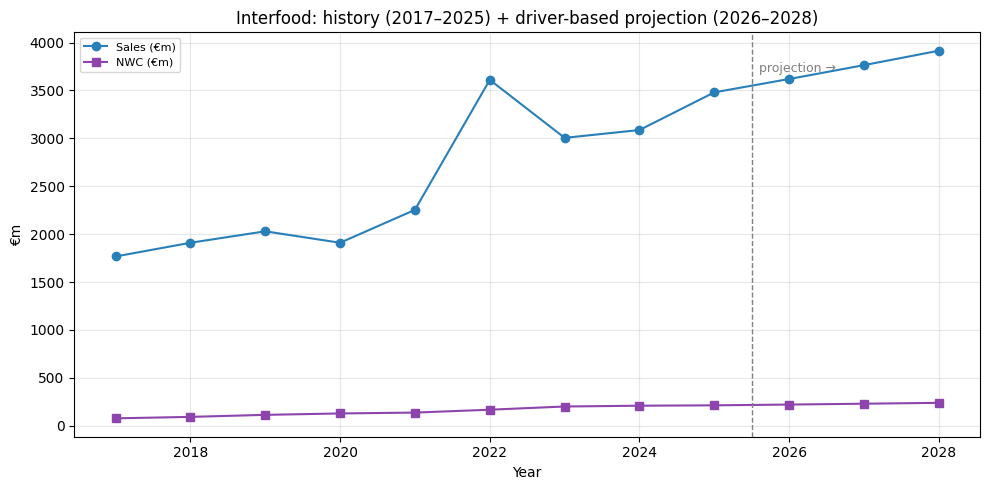

In [3]:
# Build combined actual + projected series for key metrics
hist = wide[["sales", "net_result", "net_working_capital", "equity", "solvency_pct"]].copy()

combined = pd.concat([hist, proj[hist.columns]])
combined_m = combined.copy()
for c in ["sales", "net_result", "net_working_capital", "equity"]:
    combined_m[c] = combined_m[c] / 1000

fig, ax1 = plt.subplots()
split = BASE + 0.5

ax1.plot(combined_m.index, combined_m["sales"], marker="o", color="#2980b9", label="Sales (€m)")
ax1.plot(combined_m.index, combined_m["net_working_capital"], marker="s", color="#8e44ad", label="NWC (€m)")
ax1.axvline(split, color="gray", linestyle="--", linewidth=1)
ax1.text(split+0.1, ax1.get_ylim()[1]*0.9, "projection →", color="gray", fontsize=9)
ax1.set_ylabel("€m"); ax1.set_xlabel("Year")
ax1.set_title("Interfood: history (2017–2025) + driver-based projection (2026–2028)")
ax1.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig(charts_dir / "07_projection.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# Simple one-way sensitivity: 2028 net result across net-margin assumptions
margin_grid = [0.006, 0.010, 0.012, 0.015, 0.020]  # 0.6% (2025 low) to 2.0%
sales_2028 = base["sales"] * (1 + drivers["sales_growth"])**3

sens = pd.DataFrame({
    "net_margin_pct": [f"{m:.1%}" for m in margin_grid],
    "2028_net_result_eur_m": [round(sales_2028 * m / 1000, 1) for m in margin_grid],
})
print(f"2028 projected sales: €{sales_2028/1000:,.0f}m")
print("Sensitivity of 2028 net result to net-margin assumption:")
sens

2028 projected sales: €3,914m
Sensitivity of 2028 net result to net-margin assumption:


,net_margin_pct,2028_net_result_eur_m
0,0.6%,23.5
1,1.0%,39.1
2,1.2%,47.0
3,1.5%,58.7
4,2.0%,78.3


### Result

The sensitivity table makes the core uncertainty explicit: at the projected ~€3.9bn of 2028 sales, net result ranges from ~€23m (at 2025's depressed 0.6% margin) to ~€78m (at a strong 2.0% margin) — a **3x swing driven entirely by margin**, not volume. This is the honest headline of any Interfood projection: the top line is relatively predictable, but the bottom line hinges on a thin, volatile margin that no forecast can pin down. It's a feature of the business, not a weakness of the model — and it's exactly why management steers on economic profit and risk discipline rather than revenue targets.

## Conclusion

**What we achieved:**
- Built a transparent, driver-based projection (2026–2028) linking growth, margin, and working-capital intensity through to net result, equity, and solvency.
- Made every assumption explicit and editable, and grounded each in the historical ranges from notebook 03.
- Showed via sensitivity that the **bottom line is margin-driven** — a ~3x swing in projected profit across a plausible margin range.

**Honest limitations (stated, not hidden):**
- This is a summary-metric projection with simplified statement linkage, not a fully articulated three-statement model. It's directional, built on nine data points.
- A full line-item model (payables, receivables, inventory, debt, capex, depreciation tying to the cent) is a separate build requiring statement-level data.

**What's next:**
- **`06_scenario_and_goalseek.ipynb`** — interactive stress-testing and reverse (goal-seek) modelling on top of this projection.